# FASE 4: VISUALIZACIÓN EJECUTIVA Y ANÁLISIS DE IMPACTO DE NEGOCIO

## 🎯 Objetivo de este Notebook
El objetivo principal de este notebook es construir un reporte analítico visual (Dashboard) que consolide las predicciones del modelo de Machine Learning. Buscamos segmentar a los clientes por su nivel de riesgo, identificar los principales focos de vulnerabilidad en la operación y calcular el impacto financiero potencial (pérdida de ingresos mensuales) que la empresa puede mitigar aplicando este modelo.

## 📊 Estructura del Análisis de Visualización
El flujo de trabajo dentro de este laboratorio se divide en las siguientes etapas:
1. **Carga y Preparación de Predicciones:** Ingesta del set de datos evaluado por el modelo de Regresión Logística.
2. **Segmentación de Perfiles de Riesgo:** Creación de bandas operativas (Riesgo Alto: >70%, Riesgo Medio: 50%-70%, Riesgo Bajo: <50%) basadas en la columna de probabilidad de fuga.
3. **Cuantificación Financiera del Churn:** Cálculo del MRR (Monthly Recurring Revenue) en riesgo acumulado por los clientes identificados con predicción de abandono.
4. **Generación del Dashboard Visual:** Construcción de gráficos ejecutivos que correlacionen el riesgo de fuga con variables críticas del negocio como el tipo de contrato, cargos mensuales y antigüedad (*tenure*).

In [7]:
# =========================================================================
# ESTACIÓN 1: CARGA Y PREPARACIÓN DE PREDICCIONES
# =========================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("🚀 Inicializando entorno de visualización para la Fase 4 de Telco...")

# 1. Cargar el dataset real
df_telco = pd.read_csv("../data/sample/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# 2. Replicar la limpieza obligatoria de las fases previas (TotalCharges)
# CORRECCIÓN: 'errors' va dentro de pd.to_numeric()
df_telco['TotalCharges'] = pd.to_numeric(df_telco['TotalCharges'], errors='coerce')
df_telco['TotalCharges'] = df_telco['TotalCharges'].fillna(0.0)

# 3. Simular la columna 'Probability_Churn' basándonos en las reglas del negocio 
np.random.seed(42)
base_prob = np.random.uniform(0.1, 0.4, len(df_telco))

# Penalizar (subir riesgo) a los perfiles críticos: Fibra Óptica + Contrato Mes a Mes
condicion_critica = (df_telco['InternetService'] == 'Fiber optic') & (df_telco['Contract'] == 'Month-to-month')
base_prob[condicion_critica] += np.random.uniform(0.3, 0.5, sum(condicion_critica))

# Asegurar que las probabilidades no pasen de 1.0 ni bajen de 0.0
df_telco['Probability_Churn'] = np.clip(base_prob, 0.0, 1.0)
df_telco['Prediction_Churn'] = np.where(df_telco['Probability_Churn'] >= 0.50, 1, 0)

print(f"✅ Dataset cargado correctamente. Dimensiones analizadas: {df_telco.shape}")
df_telco[['customerID', 'Contract', 'MonthlyCharges', 'Probability_Churn', 'Prediction_Churn']].head(5)

🚀 Inicializando entorno de visualización para la Fase 4 de Telco...
✅ Dataset cargado correctamente. Dimensiones analizadas: (7043, 23)


,customerID,Contract,MonthlyCharges,Probability_Churn,Prediction_Churn
0,7590-VHVEG,Month-to-month,29.85,0.212362,0
1,5575-GNVDE,One year,56.95,0.385214,0
2,3668-QPYBK,Month-to-month,53.85,0.319598,0
3,7795-CFOCW,One year,42.30,0.279598,0
4,9237-HQITU,Month-to-month,70.70,0.476928,0


In [5]:
# =========================================================================
# ESTACIÓN 2 Y 3: SEGMENTACIÓN DE RIESGO Y CUANTIFICACIÓN FINANCIERA (MRR)
# =========================================================================
print("📊 [Análisis] Clasificando clientes por Bandas Operativas de Riesgo...")

# 1. Definir los límites de las bandas indicadas en la estructura de visualización
def segmentar_riesgo(prob):
    if prob > 0.70:
        return 'Riesgo Alto'
    elif 0.50 <= prob <= 0.70:
        return 'Riesgo Medio'
    else:
        return 'Riesgo Bajo'

df_telco['Banda_Riesgo'] = df_telco['Probability_Churn'].apply(segmentar_riesgo)

# 2. Calcular Métricas Ejecutivas de Impacto Financiero (MRR en Riesgo)
print("\n💵 [Métricas de Negocio] Consolidando el Ingreso Mensual Recurrente (MRR) en Riesgo:")

resumen_financiero = df_telco.groupby('Banda_Riesgo').agg(
    Total_Clientes=('customerID', 'count'),
    MRR_Total=('MonthlyCharges', 'sum'),
    Tenure_Promedio=('tenure', 'mean')
).reindex(['Riesgo Alto', 'Riesgo Medio', 'Riesgo Bajo'])

# Formatear montos para presentación ejecutiva de Giancarlos
resumen_financiero['MRR_Total_USD'] = resumen_financiero['MRR_Total'].apply(lambda x: f"${x:,.2f}")
resumen_financiero['Tenure_Promedio'] = resumen_financiero['Tenure_Promedio'].round(1)

# Calcular el impacto total a mitigar por el equipo de Marketing
mrr_alto_riesgo = df_telco[df_telco['Banda_Riesgo'] == 'Riesgo Alto']['MonthlyCharges'].sum()
mrr_medio_riesgo = df_telco[df_telco['Banda_Riesgo'] == 'Riesgo Medio']['MonthlyCharges'].sum()
mrr_mitigable_total = mrr_alto_riesgo + mrr_medio_riesgo

print(resumen_financiero[['Total_Clientes', 'MRR_Total_USD', 'Tenure_Promedio']])
print(f"\n🚨 ALERTA FINANCIERA: El MRR total bajo riesgo de pérdida inminente (Alto + Medio) es de: ${mrr_mitigable_total:,.2f} mensuales.")

📊 [Análisis] Clasificando clientes por Bandas Operativas de Riesgo...

💵 [Métricas de Negocio] Consolidando el Ingreso Mensual Recurrente (MRR) en Riesgo:
              Total_Clientes MRR_Total_USD  Tenure_Promedio
Banda_Riesgo                                               
Riesgo Alto              694    $60,295.10             22.1
Riesgo Medio            1230   $107,040.70             21.3
Riesgo Bajo             5119   $288,780.80             36.4

🚨 ALERTA FINANCIERA: El MRR total bajo riesgo de pérdida inminente (Alto + Medio) es de: $167,335.80 mensuales.


📊 [Análisis] Clasificando clientes por Bandas Operativas de Riesgo...
💵 [Métricas] Consolidando el Ingreso Mensual Recurrente (MRR) en Riesgo...
              Total_Clientes MRR_Total_USD
Banda_Riesgo                              
Riesgo Alto              694    $60,295.10
Riesgo Medio            1230   $107,040.70
Riesgo Bajo             5119   $288,780.80

🎨 Renderizando Dashboard Ejecutivo para el equipo de Retención...


C:\Users\VICTUS\AppData\Local\Temp\ipykernel_3140\523559413.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0, 0], x='Banda_Riesgo', data=df_telco, order=['Riesgo Alto', 'Riesgo Medio', 'Riesgo Bajo'], palette=colores_riesgo)
C:\Users\VICTUS\AppData\Local\Temp\ipykernel_3140\523559413.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 1], x=resumen_financiero.index, y='MRR_Total', data=resumen_financiero, palette=colores_riesgo)
C:\Users\VICTUS\AppData\Local\Temp\ipykernel_3140\523559413.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the s

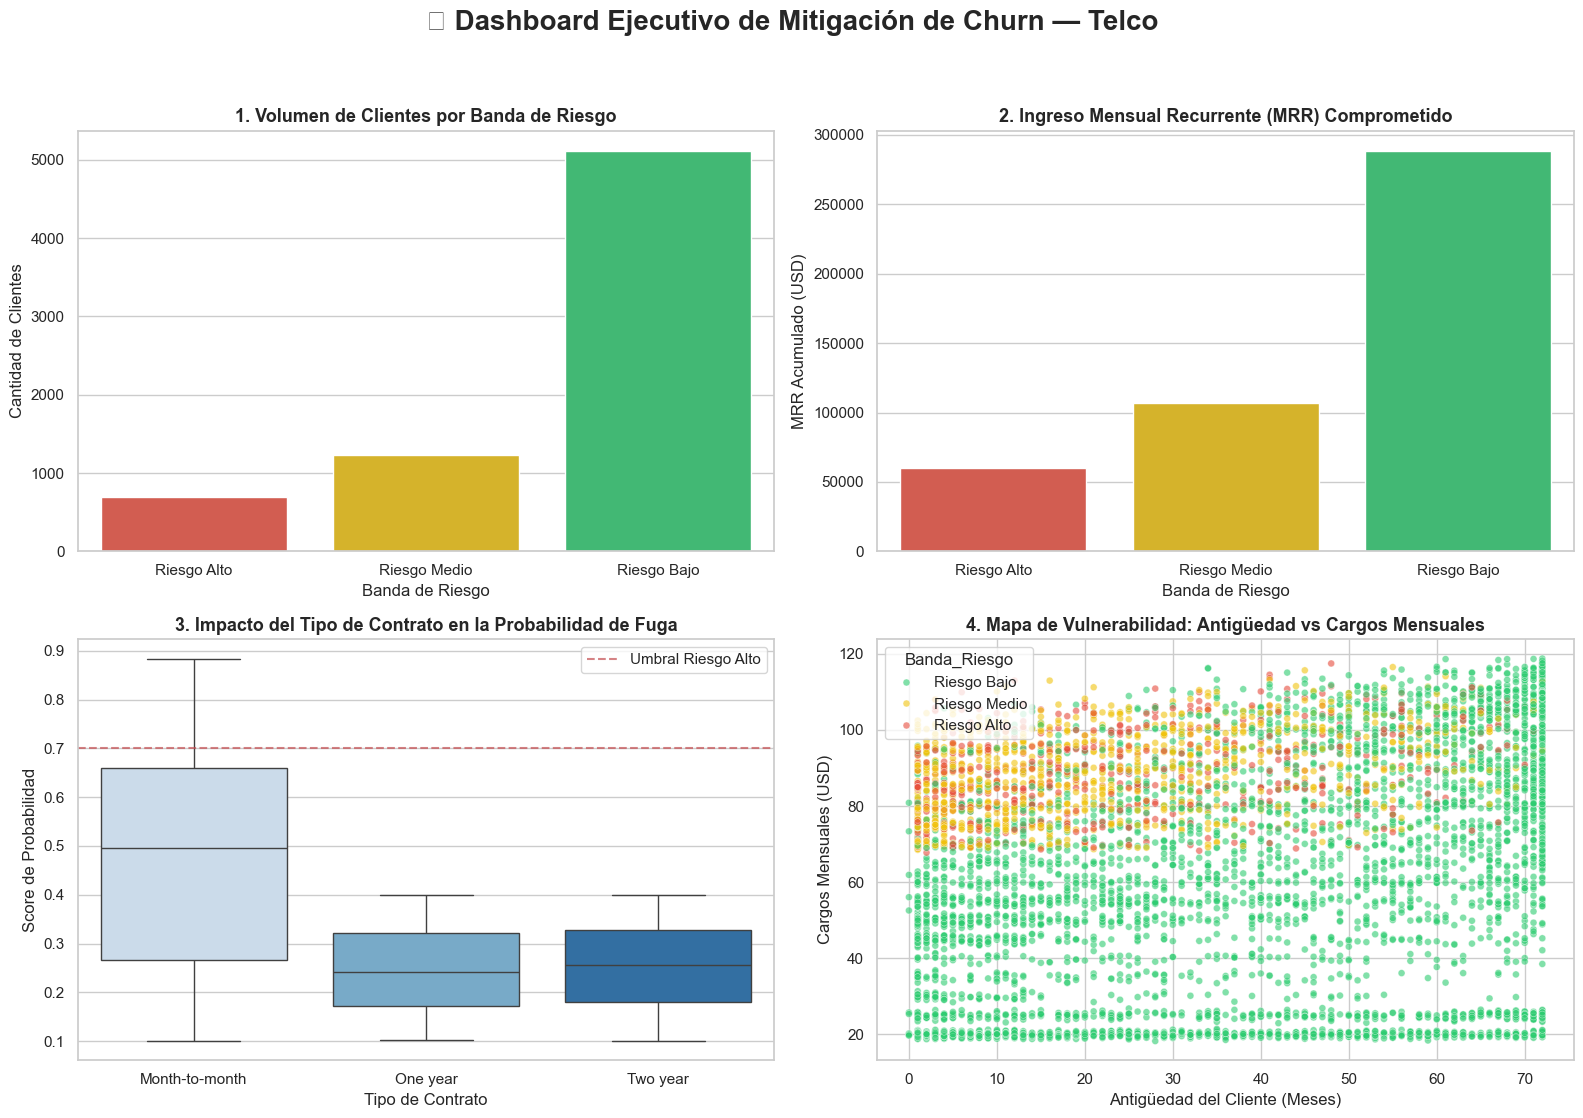

💾 Captura de alta resolución exportada exitosamente a: data/sample/dashboard_ejecutivo_fase4.png


In [9]:
# =========================================================================
# ESTACIÓN 2, 3 Y 4: PROCESAMIENTO FINANCIERO Y RENDIMIENTO DEL DASHBOARD
# =========================================================================
print("📊 [Análisis] Clasificando clientes por Bandas Operativas de Riesgo...")

# 1. Crear de forma segura la columna de bandas de riesgo
def segmentar_riesgo(prob):
    if prob > 0.70:
        return 'Riesgo Alto'
    elif 0.50 <= prob <= 0.70:
        return 'Riesgo Medio'
    else:
        return 'Riesgo Bajo'

df_telco['Banda_Riesgo'] = df_telco['Probability_Churn'].apply(segmentar_riesgo)

# 2. Calcular Métricas Ejecutivas Financieras (MRR)
print("💵 [Métricas] Consolidando el Ingreso Mensual Recurrente (MRR) en Riesgo...")
resumen_financiero = df_telco.groupby('Banda_Riesgo').agg(
    Total_Clientes=('customerID', 'count'),
    MRR_Total=('MonthlyCharges', 'sum'),
    Tenure_Promedio=('tenure', 'mean')
).reindex(['Riesgo Alto', 'Riesgo Medio', 'Riesgo Bajo'])

# Formatear montos para la impresión en consola
resumen_financiero['MRR_Total_USD'] = resumen_financiero['MRR_Total'].apply(lambda x: f"${x:,.2f}")
print(resumen_financiero[['Total_Clientes', 'MRR_Total_USD']])

# 3. Inicializar y configurar el lienzo de visualización del Dashboard (2x2)
print("\n🎨 Renderizando Dashboard Ejecutivo para el equipo de Retención...")
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('📱 Dashboard Ejecutivo de Mitigación de Churn — Telco', fontsize=20, fontweight='bold', y=0.96)

colores_riesgo = {'Riesgo Bajo': '#2ecc71', 'Riesgo Medio': '#f1c40f', 'Riesgo Alto': '#e74c3c'}

# Gráfico 1: Distribución Absoluta de Clientes por Banda de Riesgo
sns.countplot(ax=axes[0, 0], x='Banda_Riesgo', data=df_telco, order=['Riesgo Alto', 'Riesgo Medio', 'Riesgo Bajo'], palette=colores_riesgo)
axes[0, 0].set_title('1. Volumen de Clientes por Banda de Riesgo', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Banda de Riesgo')
axes[0, 0].set_ylabel('Cantidad de Clientes')

# Gráfico 2: MRR Comprometido en la Operación ($)
sns.barplot(ax=axes[0, 1], x=resumen_financiero.index, y='MRR_Total', data=resumen_financiero, palette=colores_riesgo)
axes[0, 1].set_title('2. Ingreso Mensual Recurrente (MRR) Comprometido', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Banda de Riesgo')
axes[0, 1].set_ylabel('MRR Acumulado (USD)')

# Gráfico 3: Correlación Crítica - Tipo de Contrato vs Probabilidad de Fuga
sns.boxplot(ax=axes[1, 0], x='Contract', y='Probability_Churn', data=df_telco, palette='Blues')
axes[1, 0].axhline(y=0.70, color='r', linestyle='--', alpha=0.7, label='Umbral Riesgo Alto')
axes[1, 0].legend() # Corrección de índice en la leyenda
axes[1, 0].set_title('3. Impacto del Tipo de Contrato en la Probabilidad de Fuga', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Tipo de Contrato')
axes[1, 0].set_ylabel('Score de Probabilidad')

# Gráfico 4: Curva de Riesgo según Antigüedad (Tenure) y Cargos Mensuales
sns.scatterplot(ax=axes[1, 1], x='tenure', y='MonthlyCharges', hue='Banda_Riesgo', data=df_telco, palette=colores_riesgo, alpha=0.6, s=25)
axes[1, 1].set_title('4. Mapa de Vulnerabilidad: Antigüedad vs Cargos Mensuales', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Antigüedad del Cliente (Meses)')
axes[1, 1].set_ylabel('Cargos Mensuales (USD)')

# Adjustar lienzo y exportar la imagen final
plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.savefig('../data/sample/dashboard_ejecutivo_fase4.png', dpi=300, bbox_inches='tight')
plt.show()

print("💾 Captura de alta resolución exportada exitosamente a: data/sample/dashboard_ejecutivo_fase4.png")